In [ ]:
# =========================================
#Libs
# =========================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
# -----------------------------
# Utility: image display
# -----------------------------
def show_image(title, img, cmap=None, figsize=(8, 5)):
    plt.figure(figsize=figsize)
    if len(img.shape) == 2:
        plt.imshow(img, cmap=cmap if cmap else 'gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

In [ ]:
# -----------------------------
# Step 1: Upload and load image
# -----------------------------
def upload_and_load_image():
    uploaded = files.upload()
    image_name = list(uploaded.keys())[0]
    img = cv2.imread(image_name)
    if img is None:
        raise ValueError("Could not read image.")
    return img, image_name

In [ ]:
# -----------------------------
# Step 2: Preprocessing
# -----------------------------
def grayscale(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def gaussian_blur(img, kernel_size=5):
    return cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)

In [ ]:
# -----------------------------
# Step 3: Canny edge detection
# -----------------------------
def canny_edges(img, low_threshold=50, high_threshold=150):
    return cv2.Canny(img, low_threshold, high_threshold)

In [ ]:
# -----------------------------
# Step 4: Region of Interest
# -----------------------------
def region_of_interest(img):
    """
    Apply a trapezoid mask to focus on the road region.
    """
    height, width = img.shape[:2]

    # Define a trapezoid ROI
    polygons = np.array([[
        (int(0.1 * width), height),
        (int(0.45 * width), int(0.6 * height)),
        (int(0.55 * width), int(0.6 * height)),
        (int(0.9 * width), height)
    ]], dtype=np.int32)

    mask = np.zeros_like(img)

    if len(img.shape) == 2:
        cv2.fillPoly(mask, polygons, 255)
    else:
        cv2.fillPoly(mask, polygons, (255,) * img.shape[2])

    masked = cv2.bitwise_and(img, mask)
    return masked, polygons

In [ ]:
# -----------------------------
# Step 5: Hough Line Transform
# -----------------------------
def hough_lines(img):
    """
    Detect line segments using probabilistic Hough transform.
    """
    lines = cv2.HoughLinesP(
        img,
        rho=2,
        theta=np.pi / 180,
        threshold=50,
        minLineLength=40,
        maxLineGap=100
    )
    return lines


In [ ]:
# -----------------------------
# Step 6: Separate left/right lanes
# -----------------------------
def make_line_points(y1, y2, line_params):
    """
    Convert slope-intercept form into two endpoints.
    """
    slope, intercept = line_params
    if abs(slope) < 1e-6:
        return None

    x1 = int((y1 - intercept) / slope)
    x2 = int((y2 - intercept) / slope)
    return ((x1, int(y1)), (x2, int(y2)))


def average_slope_intercept(img, lines):
    """
    Average detected line segments into one left lane and one right lane.
    """
    left_fit = []
    right_fit = []

    if lines is None:
        return None, None

    for line in lines:
        for x1, y1, x2, y2 in line:
            if x2 == x1:
                continue  # skip vertical lines

            slope = (y2 - y1) / (x2 - x1)
            intercept = y1 - slope * x1

            # Filter out nearly horizontal lines
            if abs(slope) < 0.5:
                continue

            if slope < 0:
                left_fit.append((slope, intercept))
            else:
                right_fit.append((slope, intercept))

    height = img.shape[0]
    y1 = height
    y2 = int(height * 0.6)

    left_lane = None
    right_lane = None

    if len(left_fit) > 0:
        left_avg = np.mean(left_fit, axis=0)
        left_lane = make_line_points(y1, y2, left_avg)

    if len(right_fit) > 0:
        right_avg = np.mean(right_fit, axis=0)
        right_lane = make_line_points(y1, y2, right_avg)

    return left_lane, right_lane

In [ ]:
# -----------------------------
# Step 7: Draw detected lanes
# -----------------------------
def draw_lane_lines(img, left_lane, right_lane, color=(0, 255, 0), thickness=8):
    line_img = np.zeros_like(img)

    if left_lane is not None:
        cv2.line(line_img, left_lane[0], left_lane[1], color, thickness)

    if right_lane is not None:
        cv2.line(line_img, right_lane[0], right_lane[1], color, thickness)

    overlay = cv2.addWeighted(img, 0.8, line_img, 1.0, 0)
    return overlay, line_img


In [ ]:
# -----------------------------
# Bonus: Color threshold
# -----------------------------
def color_threshold(img):
    """
    Detect white and yellow lane colors in HLS space.
    """
    hls = cv2.cvtColor(img, cv2.COLOR_BGR2HLS)

    # White mask
    lower_white = np.array([0, 200, 0], dtype=np.uint8)
    upper_white = np.array([255, 255, 255], dtype=np.uint8)
    white_mask = cv2.inRange(hls, lower_white, upper_white)

    # Yellow mask
    lower_yellow = np.array([15, 30, 115], dtype=np.uint8)
    upper_yellow = np.array([35, 204, 255], dtype=np.uint8)
    yellow_mask = cv2.inRange(hls, lower_yellow, upper_yellow)

    combined = cv2.bitwise_or(white_mask, yellow_mask)
    return combined


def combine_edge_and_color(edge_img, color_mask):
    return cv2.bitwise_or(edge_img, color_mask)


In [ ]:
# -----------------------------
# Main pipeline
# -----------------------------
def lane_detection_pipeline(img):
    gray = grayscale(img)
    blur = gaussian_blur(gray, kernel_size=5)
    edges = canny_edges(blur, low_threshold=50, high_threshold=150)

    color_mask = color_threshold(img)
    combined_mask = combine_edge_and_color(edges, color_mask)

    roi_edges, roi_polygon = region_of_interest(combined_mask)

    lines = hough_lines(roi_edges)
    left_lane, right_lane = average_slope_intercept(img, lines)

    final_overlay, lane_only = draw_lane_lines(img, left_lane, right_lane)

    return {
        "gray": gray,
        "blur": blur,
        "edges": edges,
        "color_mask": color_mask,
        "combined_mask": combined_mask,
        "roi_edges": roi_edges,
        "lines": lines,
        "left_lane": left_lane,
        "right_lane": right_lane,
        "lane_only": lane_only,
        "final_overlay": final_overlay,
        "roi_polygon": roi_polygon
    }

Saving Screenshot 2026-03-09 214047.png to Screenshot 2026-03-09 214047 (1).png


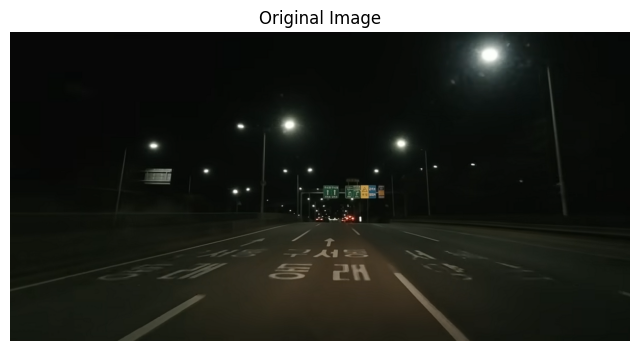

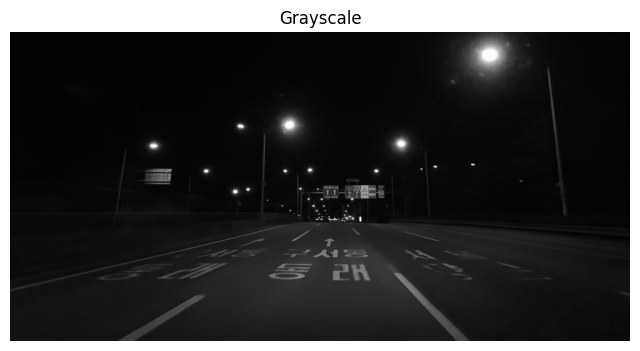

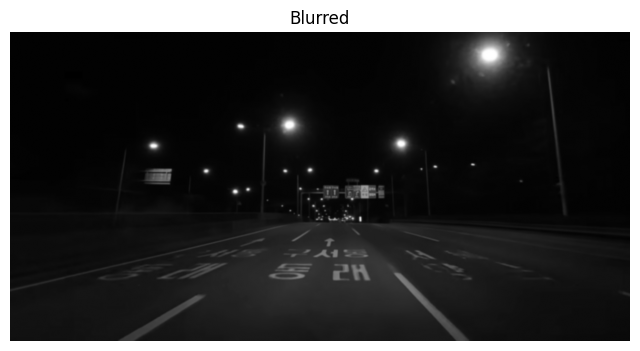

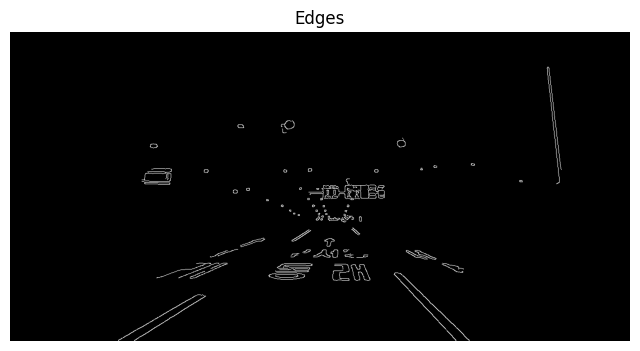

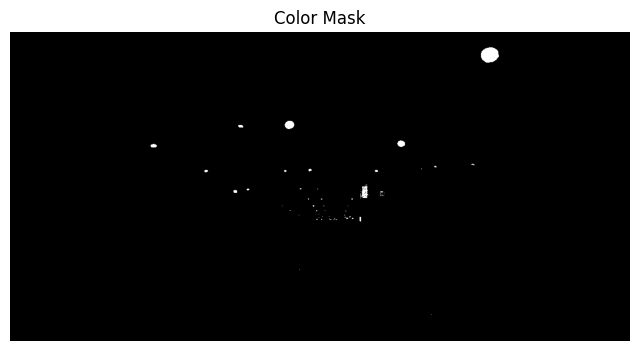

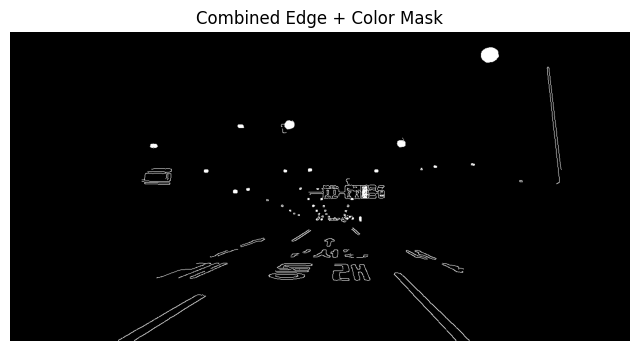

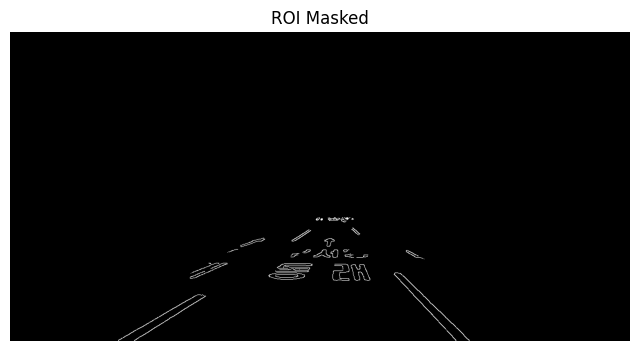

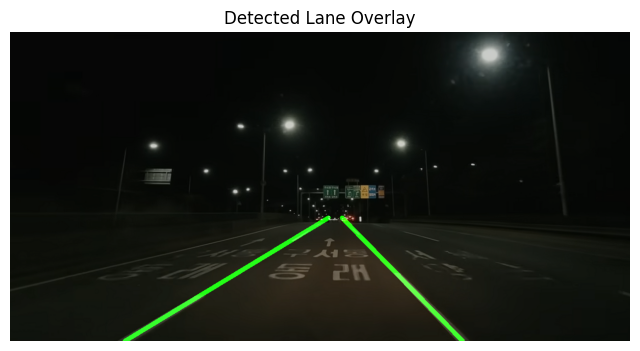

In [ ]:
# -----------------------------
# Run on one image
# -----------------------------
img, image_name = upload_and_load_image()
results = lane_detection_pipeline(img)

show_image("Original Image", img)
show_image("Grayscale", results["gray"], cmap="gray")
show_image("Blurred", results["blur"], cmap="gray")
show_image("Edges", results["edges"], cmap="gray")
show_image("Color Mask", results["color_mask"], cmap="gray")
show_image("Combined Edge + Color Mask", results["combined_mask"], cmap="gray")
show_image("ROI Masked", results["roi_edges"], cmap="gray")
show_image("Detected Lane Overlay", results["final_overlay"])